# P&ID component detection

**Goal:** given a P&ID image, draw a labelled bounding box around each component (tanks, pumps, valves, instruments, …).

**Data:** [PID2Graph](https://zenodo.org/records/14803338) (Stürmer, Graumann & Koch, 2025; CC BY-SA 4.0). We use only the full-sheet `Complete/` part:

| Subset | Sheets | Kind | Notes |
|---|---|---|---|
| `PID2Graph Synthetic` | 250 | synthetic, 7000×4500 | has `tank` and `pump` |
| `PID2Graph OPEN100` | 12 | **real** (OPEN100 reactor design) | our honest test set |
| `Dataset PID` | 500 | synthetic (Paliwal et al. 2021) | no `tank` / `pump` labels; 2.5 GB, fetched separately |

Fetch with `uv run python scripts/fetch_pid2graph.py` (add `"Complete/Dataset PID"` for the large set).

**Contents**
1. Load annotations
2. Label & box-size statistics
3. Look at sheets with ground-truth boxes
4. Class mapping (what counts as a "component")
5. Train / val / test split by sheet
6. PyTorch dataset + sanity check

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import pandas as pd
from PIL import Image

Image.MAX_IMAGE_PIXELS = None  # sheets are up to 7000x4500
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
DATA = ROOT / "data" / "raw" / "PID2Graph" / "Complete"
SUBSETS = ["PID2Graph Synthetic", "PID2Graph OPEN100", "Dataset PID"]

## 1. Load annotations

Each sheet has an image plus a `.graphml` file. Symbols are graph **nodes** with a `label` and a box (`xmin, ymin, xmax, ymax`); lines are **edges**. We only need the nodes.

In [2]:
def load_sheet(graphml: Path) -> list[dict]:
    g = nx.read_graphml(graphml)
    out = []
    for _, d in g.nodes(data=True):
        x0, x1 = sorted((float(d["xmin"]), float(d["xmax"])))  # a few boxes are stored inverted
        y0, y1 = sorted((float(d["ymin"]), float(d["ymax"])))
        out.append({"label": d["label"], "xmin": x0, "ymin": y0, "xmax": x1, "ymax": y1})
    return out


def find_image(graphml: Path) -> Path | None:
    for ext in (".png", ".jpg"):
        p = graphml.with_suffix(ext)
        if p.exists():
            return p
    return None


rows, sheets = [], []
for subset in SUBSETS:
    for gml in sorted((DATA / subset).glob("*.graphml"), key=lambda p: int(p.stem)):
        img = find_image(gml)
        if img is None:  # Dataset PID may still be downloading
            continue
        W, H = Image.open(img).size  # reads the header only
        sheet_id = f"{subset}/{gml.stem}"
        sheets.append({"sheet": sheet_id, "subset": subset, "image": img, "W": W, "H": H})
        for b in load_sheet(gml):
            rows.append({"sheet": sheet_id, "subset": subset, "W": W, "H": H, **b})

sheets = pd.DataFrame(sheets)
boxes = pd.DataFrame(rows)
boxes["w"] = boxes.xmax - boxes.xmin
boxes["h"] = boxes.ymax - boxes.ymin
# box size relative to the sheet: sqrt(box area / sheet area); 0.1 = a box about 1/10 of the sheet across
boxes["rel_size"] = np.sqrt(boxes.w * boxes.h / (boxes.W * boxes.H))

sheets.groupby("subset").agg(n_sheets=("sheet", "size"), W=("W", "median"), H=("H", "median"))

,n_sheets,W,H
subset,,,
Dataset PID,500,7168.0,4561.0
PID2Graph OPEN100,12,2789.0,1861.0
PID2Graph Synthetic,250,7000.0,4500.0


## 2. Label and box-size statistics

In [3]:
counts = boxes.pivot_table(index="label", columns="subset", values="sheet", aggfunc="size", fill_value=0)
counts["total"] = counts.sum(axis=1)
counts.sort_values("total", ascending=False)

subset,Dataset PID,PID2Graph OPEN100,PID2Graph Synthetic,total
label,,,,
connector,115077,2408,9844,127329
crossing,51182,734,17366,69282
valve,28262,257,630,29149
general,17600,234,3806,21640
instrumentation,11979,350,0,12329
arrow,1657,451,59,2167
background,2000,48,0,2048
tank,0,35,686,721
pump,0,16,421,437


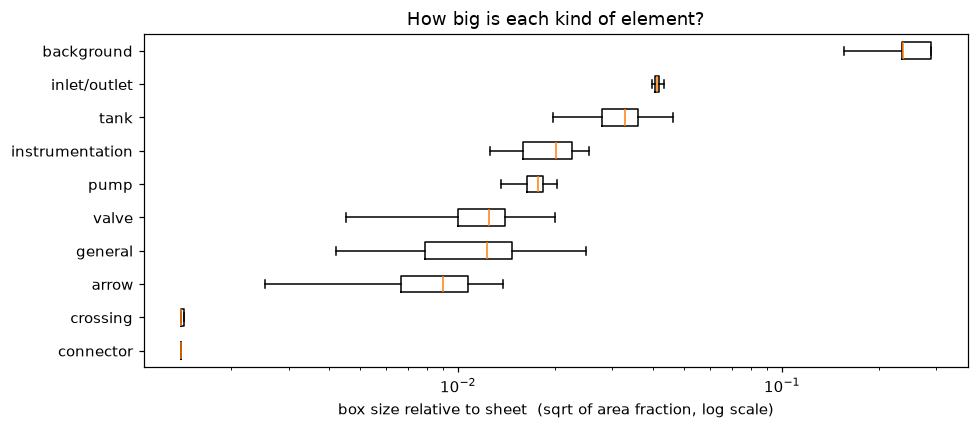

In [4]:
order = boxes.groupby("label").rel_size.median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([boxes.loc[boxes.label == l, "rel_size"] for l in order], tick_labels=order, orientation="horizontal", showfliers=False)
ax.set_xscale("log")
ax.set_xlabel("box size relative to sheet  (sqrt of area fraction, log scale)")
ax.set_title("How big is each kind of element?")
plt.tight_layout()

`connector` and `crossing` are tiny points where lines meet symbols or cross each other, which makes them graph nodes rather than components. `tank` is clearly the "big element" class. `general` covers a wide range of sizes.

## 3. Look at sheets with ground-truth boxes

In [5]:
PALETTE = plt.get_cmap("tab10")
ALL_LABELS = sorted(boxes.label.unique())
LABEL_COLOR = {l: PALETTE(i % 10) for i, l in enumerate(ALL_LABELS)}


def show_sheet(sheet_id: str, keep: set[str] | None = None, ax=None, max_side: int = 2000):
    s = sheets.set_index("sheet").loc[sheet_id]
    img = Image.open(s.image).convert("L")
    scale = min(1.0, max_side / max(img.size))
    img = img.resize((round(img.width * scale), round(img.height * scale)))
    ax = ax or plt.subplots(figsize=(14, 9))[1]
    ax.imshow(img, cmap="gray")
    b = boxes[boxes.sheet == sheet_id]
    if keep is not None:
        b = b[b.label.isin(keep)]
    for r in b.itertuples():
        ax.add_patch(mpatches.Rectangle((r.xmin * scale, r.ymin * scale), r.w * scale, r.h * scale,
                                        fill=False, lw=1.2, ec=LABEL_COLOR[r.label]))
    shown = sorted(b.label.unique())
    ax.legend(handles=[mpatches.Patch(color=LABEL_COLOR[l], label=l) for l in shown],
              loc="upper right", fontsize=7)
    ax.set_title(sheet_id)
    ax.axis("off")
    return ax

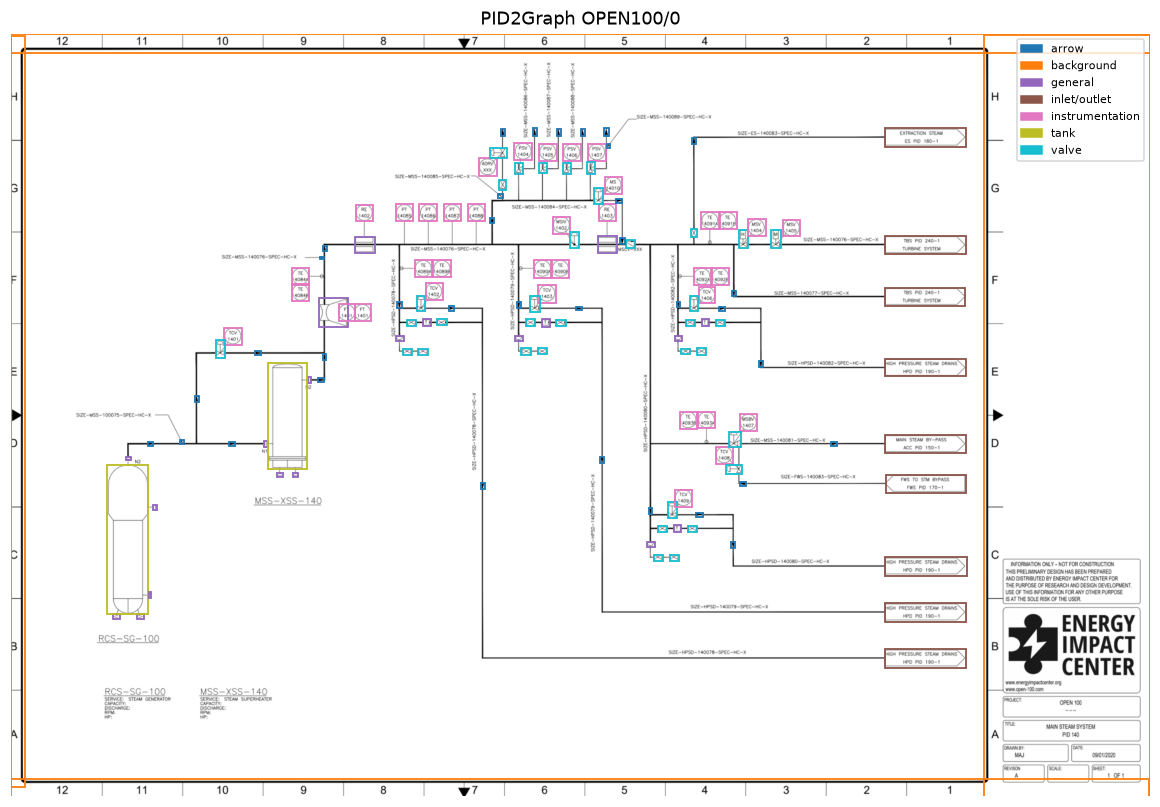

In [6]:
# a real sheet, showing everything except line-junction points
show_sheet("PID2Graph OPEN100/0", keep=set(ALL_LABELS) - {"connector", "crossing"});

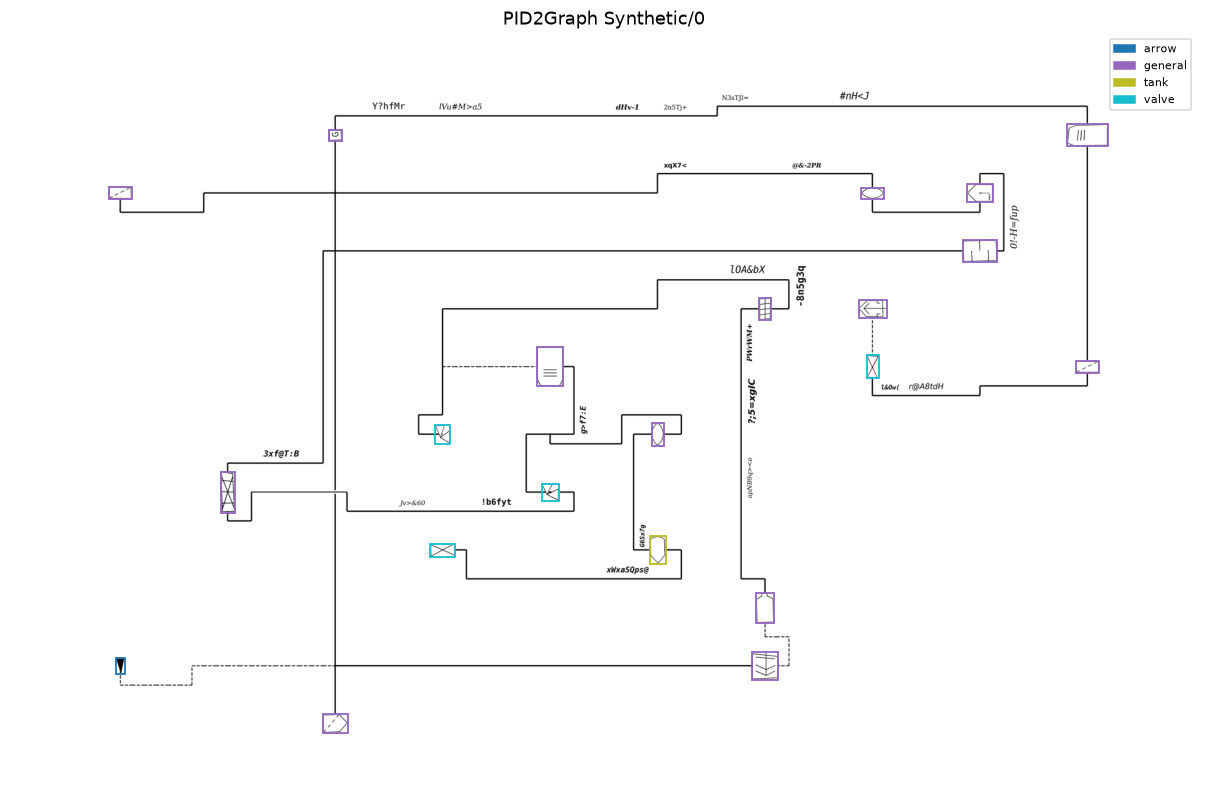

In [7]:
show_sheet("PID2Graph Synthetic/0", keep=set(ALL_LABELS) - {"connector", "crossing"});

sheet
Dataset PID/0          4
Dataset PID/1          4
Dataset PID/10         4
Dataset PID/100        4
Dataset PID/101        4
                      ..
PID2Graph OPEN100/5    4
PID2Graph OPEN100/6    4
PID2Graph OPEN100/7    4
PID2Graph OPEN100/8    4
PID2Graph OPEN100/9    4
Length: 512, dtype: int64


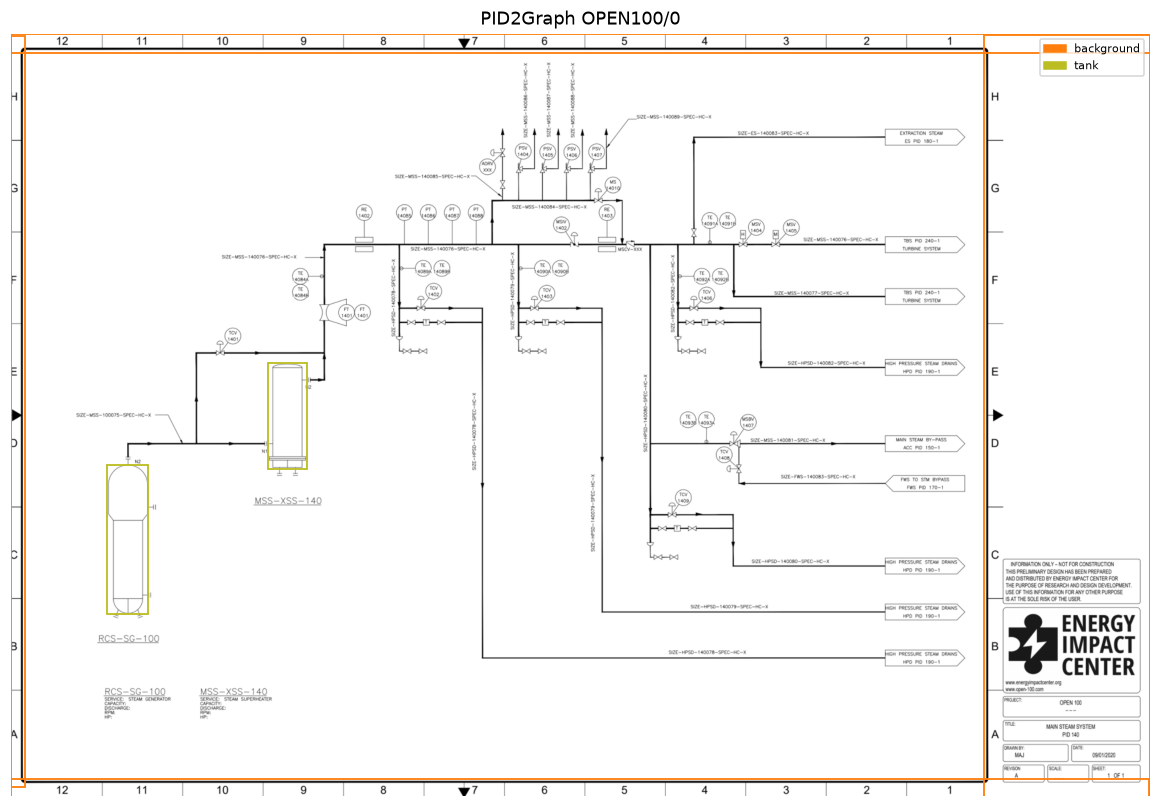

In [8]:
# what is 'background'? only OPEN100 has it
bg = boxes[boxes.label == "background"]
print(bg.groupby("sheet").size())
show_sheet(bg.sheet.iloc[0], keep={"background", "tank"});

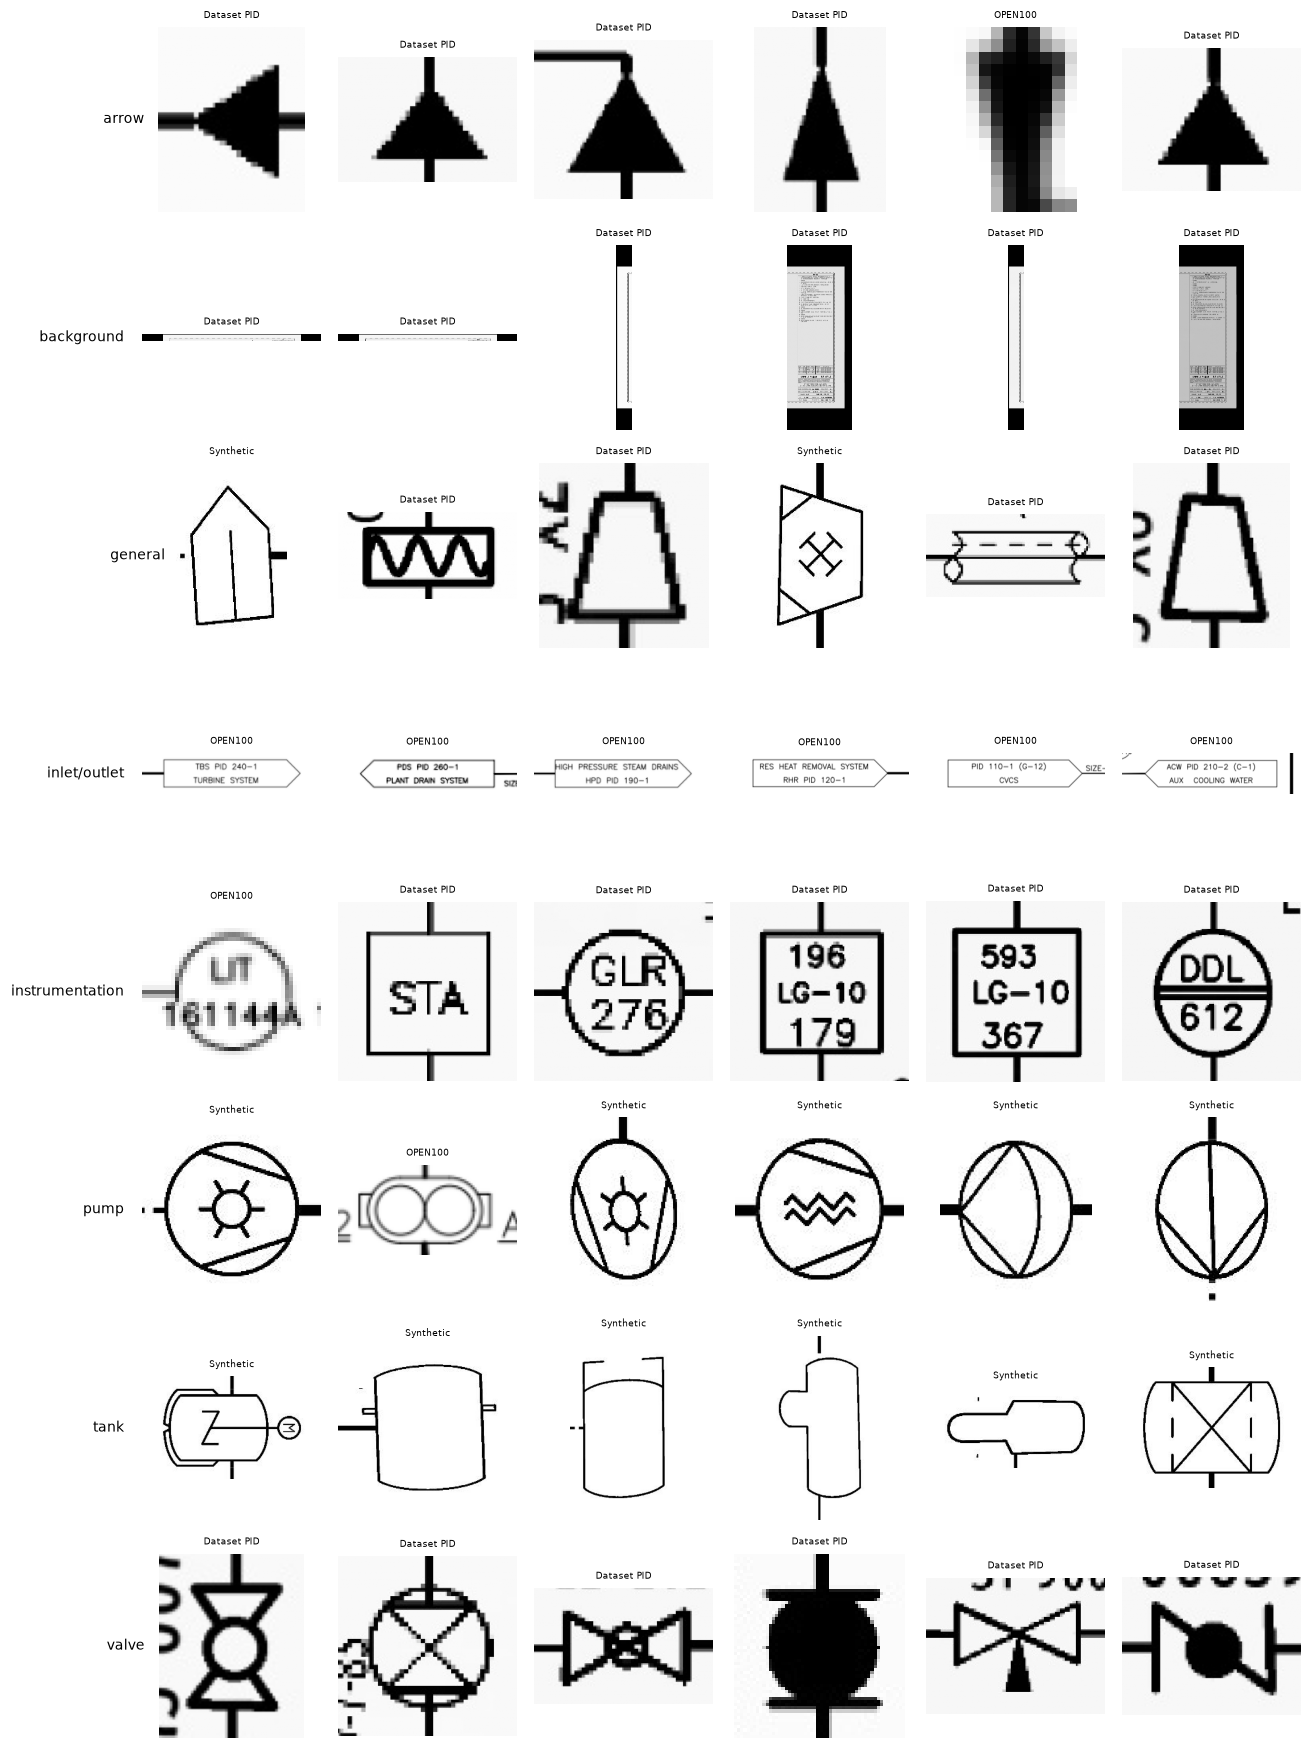

In [9]:
# close-up crops of each component class
def crop(r, pad=0.15):
    img = Image.open(sheets.set_index("sheet").loc[r.sheet, "image"]).convert("L")
    px, py = r.w * pad, r.h * pad
    return img.crop((r.xmin - px, r.ymin - py, r.xmax + px, r.ymax + py))


show = [l for l in ALL_LABELS if l not in {"connector", "crossing"}]
rng = np.random.default_rng(0)
fig, axes = plt.subplots(len(show), 6, figsize=(12, 2 * len(show)))
for i, label in enumerate(show):
    sample = boxes[boxes.label == label]
    sample = sample.iloc[rng.choice(len(sample), size=min(6, len(sample)), replace=False)]
    for j, ax in enumerate(axes[i]):
        ax.axis("off")
        if j < len(sample):
            r = sample.iloc[j]
            ax.imshow(crop(r), cmap="gray")
            ax.set_title(r.subset.replace("PID2Graph ", ""), fontsize=6)
    axes[i, 0].text(-0.1, 0.5, label, transform=axes[i, 0].transAxes, ha="right", va="center", fontsize=9)
plt.tight_layout()

## 4. Class mapping

We start with a small set of component classes. Anything mapped to `None` is dropped.

What the crops above show:
- `background` is the sheet border and title frame, not a component, so it is dropped.
- `inlet/outlet` (off-sheet connector arrows) appears only in the real OPEN100 sheets, so there is nothing to train it on. Dropped for now.
- `instrument` appears only in OPEN100 and Dataset PID. Train coverage depends on Dataset PID being downloaded.
- `general` is a mixed class: heat exchangers, filters, nozzles, and so on. It may be worth splitting later.

In [10]:
CLASS_MAP = {
    "tank": "tank",
    "pump": "pump",
    "valve": "valve",
    "instrumentation": "instrument",
    "general": "general",
    # dropped
    "connector": None,     # line/symbol junction point, not a component
    "crossing": None,      # line crossing point
    "arrow": None,         # flow arrows: tiny, and not a component
    "background": None,    # the four strips of the sheet border / title frame
    "inlet/outlet": None,  # off-sheet connectors: only in OPEN100 (test), so nothing to train on
}
unmapped = set(boxes.label) - set(CLASS_MAP)
assert not unmapped, f"add these labels to CLASS_MAP: {unmapped}"

CLASSES = sorted({c for c in CLASS_MAP.values() if c})
CLASS_TO_ID = {c: i + 1 for i, c in enumerate(CLASSES)}  # 0 = background for torchvision detectors

comp = boxes.assign(cls=boxes.label.map(CLASS_MAP)).dropna(subset=["cls"])

# Which trained run sections 7-9 load. Runs trained by nrp/train.py with --preset large / small save their class set
# in best.pt["cfg"]; their labels are then mapped with train.py's own rule (map_label), so the ground truth here
# matches what that model learned (tank/pump/equipment, or valve/instrument/small_general).
import sys
import torch
sys.path.insert(0, str(ROOT / "nrp"))
import train as nrp_train

RUN = ROOT / "runs" / "baseline"  # e.g. runs/large-v1 or runs/small-v1 after `nrp/run.sh fetch <name>`
RUN_CFG = (torch.load(RUN / "best.pt", map_location="cpu", weights_only=False).get("cfg")
           if (RUN / "best.pt").exists() else None)
if RUN_CFG:
    comp = boxes.assign(cls=[
        nrp_train.map_label(r.label, r.subset, r.w, r.h, r.W, r.H, RUN_CFG["class_map"], RUN_CFG["equipment_min_px"] or 0)
        for r in boxes.itertuples()]).dropna(subset=["cls"])
    CLASSES = RUN_CFG["classes"]
    CLASS_TO_ID = {c: i + 1 for i, c in enumerate(CLASSES)}
    print(f"using the class set of {RUN.name}: {CLASSES}")
comp.pivot_table(index="cls", columns="subset", values="sheet", aggfunc="size", fill_value=0)

subset,Dataset PID,PID2Graph OPEN100,PID2Graph Synthetic
cls,,,
general,17600,234,3806
instrument,11979,350,0
pump,0,16,421
tank,0,35,686
valve,28262,257,630


## 5. Train / val / test split by sheet

We split by **whole sheet**, never by box or tile, so no drawing appears in both train and test.

- **test:** all 12 OPEN100 sheets. These are real drawings and our honest score.
- **val:** 15% of the synthetic sheets, chosen by a hash of the sheet id. That way a sheet keeps its split as more of Dataset PID downloads.
- **train:** the rest of the synthetic sheets.

Caveat: synthetic and real sheets look different, so test scores will likely be lower than val scores. That gap is what we want to measure and reduce.

In [11]:
import zlib


def assign_split(sheet_id: str, subset: str) -> str:
    if subset == "PID2Graph OPEN100":
        return "test"
    # stable hash: a sheet keeps its split as more sheets are downloaded
    return "val" if zlib.crc32(sheet_id.encode()) % 100 < 15 else "train"


sheets["split"] = [assign_split(s, sub) for s, sub in zip(sheets.sheet, sheets.subset)]
comp = comp.assign(split=comp.sheet.map(sheets.set_index("sheet").split))
comp.pivot_table(index="cls", columns="split", values="sheet", aggfunc="size", fill_value=0)[["train", "val", "test"]]

split,train,val,test
cls,,,
general,18003,3403,234
instrument,9980,1999,350
pump,369,52,16
tank,588,98,35
valve,24102,4790,257


## 6. PyTorch dataset + sanity check

Each whole sheet is resized so its long side is `MAX_SIDE` pixels. At 2048, a typical synthetic valve is about 20 px across, which is enough for a detector, and a tank is about 150 px.

Decoding a 7000×4500 PNG takes about a second, so each resized sheet is cached twice:
- on disk under `data/cache/`, so later runs skip the slow decode;
- in RAM, since all sheets at 2048 px take about 2 GB as grayscale.

`precache()` prepares every sheet up front using threads. This replaces `DataLoader` worker processes, which don't work in Jupyter on Windows when the dataset class is defined in the notebook.

In [12]:
import torch
from torchvision.transforms.functional import to_tensor
from tqdm.auto import tqdm

MAX_SIDE = 2048
CACHE = ROOT / "data" / "cache" / str(MAX_SIDE)
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
RAM_CACHE: dict[str, tuple[np.ndarray, float]] = {}  # sheet id -> (grayscale uint8 array, scale)


def load_resized(path: Path, max_side: int = MAX_SIDE) -> tuple[Image.Image, float]:
    """Grayscale sheet as RGB with its long side = max_side, plus the scale factor applied."""
    img = Image.open(path)
    if img.mode in ("RGBA", "LA", "P"):  # flatten transparency onto white, not black
        img = img.convert("RGBA")
        img = Image.alpha_composite(Image.new("RGBA", img.size, "white"), img)
    img = img.convert("L")
    scale = max_side / max(img.size)
    img = img.resize((round(img.width * scale), round(img.height * scale)), Image.LANCZOS)
    return img.convert("RGB"), scale


class PIDDataset(torch.utils.data.Dataset):
    def __init__(self, sheet_ids, train: bool = False):
        self.sheet_ids = list(sheet_ids)
        self.train = train  # enables random horizontal flip
        self.meta = sheets.set_index("sheet")
        self.ann = {s: g for s, g in comp.groupby("sheet")}

    def __len__(self):
        return len(self.sheet_ids)

    def _image(self, sid: str) -> tuple[Image.Image, float]:
        if sid not in RAM_CACHE:
            src = self.meta.loc[sid]
            cached = CACHE / f"{sid}.png"
            if cached.exists():
                gray = Image.open(cached).convert("L")
            else:
                img, _ = load_resized(src.image)
                gray = img.convert("L")
                cached.parent.mkdir(parents=True, exist_ok=True)
                gray.save(cached)
            RAM_CACHE[sid] = (np.asarray(gray), gray.width / src.W)
        arr, scale = RAM_CACHE[sid]
        return Image.fromarray(arr).convert("RGB"), scale

    def __getitem__(self, i):
        sid = self.sheet_ids[i]
        img, scale = self._image(sid)
        a = self.ann.get(sid)
        if a is None:
            bxs, lbls = torch.zeros((0, 4)), torch.zeros((0,), dtype=torch.int64)
        else:
            bxs = torch.tensor(a[["xmin", "ymin", "xmax", "ymax"]].to_numpy(), dtype=torch.float32) * scale
            lbls = torch.tensor(a.cls.map(CLASS_TO_ID).to_numpy(), dtype=torch.int64)
        x = to_tensor(img)
        if self.train and torch.rand(()) < 0.5:
            x = x.flip(-1)
            bxs = torch.stack([x.shape[-1] - bxs[:, 2], bxs[:, 1], x.shape[-1] - bxs[:, 0], bxs[:, 3]], dim=1)
        return x, {"boxes": bxs, "labels": lbls, "sheet": sid}


def ids(split):
    return sheets.loc[sheets.split == split, "sheet"]


datasets = {"train": PIDDataset(ids("train"), train=True), "val": PIDDataset(ids("val")), "test": PIDDataset(ids("test"))}


def precache(workers: int = 8):
    """Resize and cache every sheet once, in parallel. PIL releases the GIL while decoding and resizing."""
    from concurrent.futures import ThreadPoolExecutor
    ds = PIDDataset(sheets.sheet)
    with ThreadPoolExecutor(workers) as pool:
        list(tqdm(pool.map(ds._image, ds.sheet_ids), total=len(ds), desc="caching sheets"))
    gb = sum(a.nbytes for a, _ in RAM_CACHE.values()) / 2**30
    print(f"{len(RAM_CACHE)} sheets in RAM ({gb:.1f} GB)")


precache()
{k: len(v) for k, v in datasets.items()}

caching sheets:   0%|          | 0/762 [00:00<?, ?it/s]

762 sheets in RAM (1.9 GB)


{'train': 635, 'val': 115, 'test': 12}

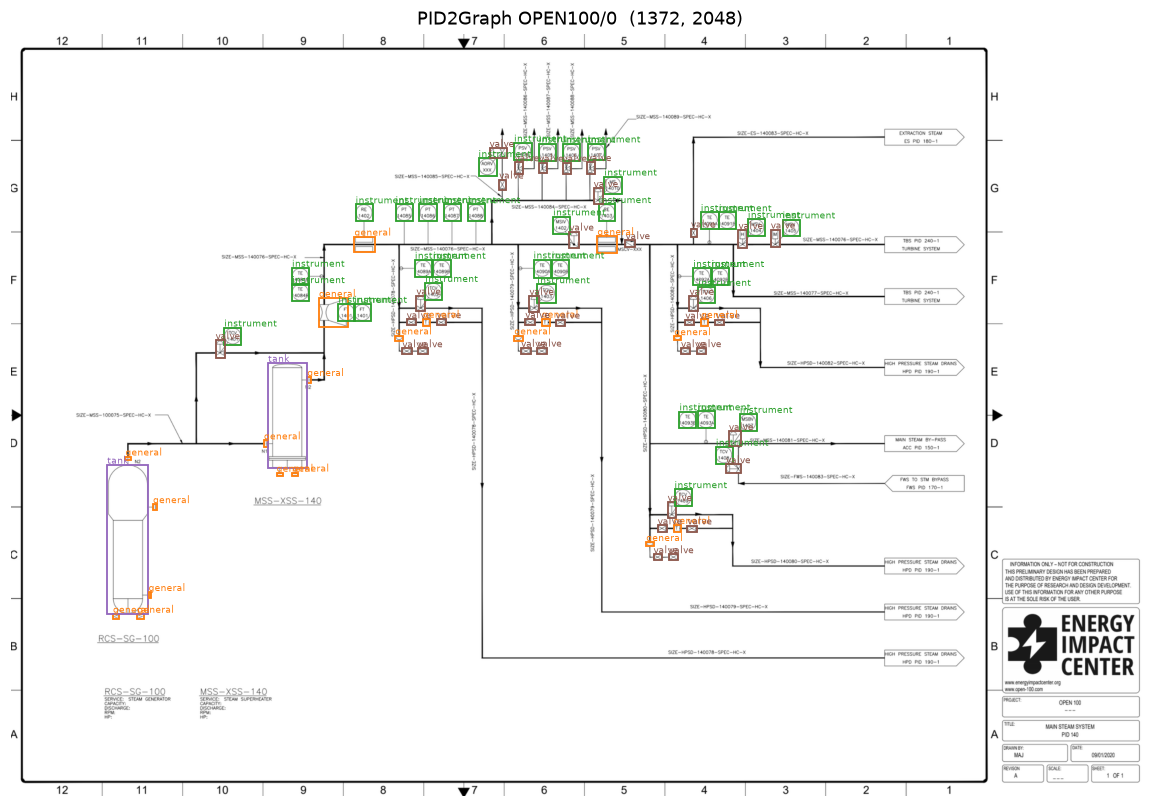

In [13]:
def draw_boxes(ax, boxes_xyxy, labels, scores=None, lw=1.2):
    for k, ((x0, y0, x1, y1), l) in enumerate(zip(boxes_xyxy, labels)):
        c = PALETTE(l % 10)
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, lw=lw, ec=c))
        txt = ID_TO_CLASS[l] if scores is None else f"{ID_TO_CLASS[l]} {scores[k]:.2f}"
        ax.text(x0, y0 - 2, txt, color=c, fontsize=6)


# sanity check: boxes should still line up after resizing
img, tgt = datasets["test"][0]
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img.permute(1, 2, 0))
draw_boxes(ax, tgt["boxes"].tolist(), tgt["labels"].tolist())
ax.set_title(f"{tgt['sheet']}  {tuple(img.shape[1:])}")
ax.axis("off");

## 7. Train a baseline detector

**Model:** torchvision **Faster R-CNN (ResNet-50 FPN v2)**, starting from weights pretrained on COCO. Only the final classification layer is replaced to predict our classes.

Settings that matter for P&IDs:
- `min_size = max_size = MAX_SIDE`: torchvision normally shrinks images to 800 px, which would make valves about 8 px across. This keeps the sheets at 2048 px.
- `box_detections_per_img = 300`: real sheets have about 80 components or more, and the default of 100 could cut some off.
- Horizontal flip for augmentation. A mirrored P&ID is still a valid P&ID.

**Hardware:** set up for an **RTX 4070 Super (12 GB)**.
- **Mixed precision (AMP, float16)** on CUDA roughly halves activation memory and uses the tensor cores.
- **Batch size 1:** 2 sheets per batch at 2048 px took about 17 GB on the Mac without AMP. With AMP, batch 2 *may* fit in 12 GB. The epoch log shows peak GPU memory, so try `BATCH_SIZE = 2` if the peak stays under about 5 GB.
- If you get `CUDA out of memory`: keep batch 1 and lower `MAX_SIDE` in section 6 to 1600.
- The learning rate scales automatically with `BATCH_SIZE`.

**Training on NRP (recommended):** `nrp/train.py` runs this same model, data and split as a cluster Job on a 46–48 GB GPU.
```
nrp/run.sh train baseline     # submit the Job
nrp/run.sh logs baseline      # follow progress
nrp/run.sh fetch baseline     # copy best.pt, metrics and predictions into runs/baseline/
```
Once `runs/baseline/best.pt` exists, this cell loads it instead of training. Sections 8–9 then evaluate and predict locally, which needs only inference and is fine on the Mac.

To train in the notebook instead (e.g. on the 4070 Super), delete or rename that file, or set `TRAIN = True`.

In [14]:
import math
import time

from torchmetrics.detection import MeanAveragePrecision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights, fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

CKPT = RUN / "best.pt"  # RUN is set in section 4; written by `nrp/run.sh fetch`; notebook training saves here too
TRAIN = not CKPT.exists()
if TRAIN and RUN.name != "baseline":
    # local training only ever produces a 5-class baseline; never save one under a large/small run's name
    raise FileNotFoundError(f"{CKPT} is missing: run `nrp/run.sh fetch {RUN.name}` first (or set RUN to runs/baseline)")
SMOKE_TEST = False  # True = a handful of batches, just to check that everything runs
NUM_EPOCHS = 12
BATCH_SIZE = 1                   # RTX 4070 Super, 12 GB: start at 1, try 2 if peak memory allows
LR = 0.02 * BATCH_SIZE / 16      # the standard Faster R-CNN LR (0.02 at batch 16), scaled linearly
USE_AMP = DEVICE.type == "cuda"  # float16 mixed precision

torch.manual_seed(0)


def build_model(num_classes: int = len(CLASSES) + 1, pretrained: bool = True):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT if pretrained else None
    m = fasterrcnn_resnet50_fpn_v2(weights=weights, min_size=MAX_SIDE, max_size=MAX_SIDE,
                                   box_detections_per_img=300)
    m.roi_heads.box_predictor = FastRCNNPredictor(m.roi_heads.box_predictor.cls_score.in_features, num_classes)
    return m


def collate(batch):
    return tuple(zip(*batch))


def loader(split, shuffle=False):
    return torch.utils.data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=shuffle,
                                       collate_fn=collate, num_workers=0)


@torch.no_grad()
def evaluate(model, split, max_batches=None):
    """COCO-style mAP on a split, plus per-class AP."""
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox", class_metrics=True, max_detection_thresholds=[1, 100, 300])
    # map / per-class AP use 100 detections per class per image (-1 if 100 is missing); map_50 uses 300
    for b, (imgs, tgts) in enumerate(loader(split)):
        if max_batches is not None and b >= max_batches:
            break
        out = model([im.to(DEVICE) for im in imgs])
        metric.update([{k: v.cpu() for k, v in o.items()} for o in out],
                      [{"boxes": t["boxes"], "labels": t["labels"]} for t in tgts])
    r = metric.compute()
    per_class = {ID_TO_CLASS[int(c)]: float(ap) for c, ap in zip(r["classes"].reshape(-1), r["map_per_class"].reshape(-1))}
    return {"mAP": float(r["map"]), "mAP50": float(r["map_50"]), "per_class_AP": per_class}

device: mps 


In [15]:
model = build_model().to(DEVICE)
history = []

if TRAIN:
    train_loader = loader("train", shuffle=True)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=1e-4)
    n_epochs = 1 if SMOKE_TEST else NUM_EPOCHS
    steps_per_epoch = 3 if SMOKE_TEST else len(train_loader)
    total, warmup = n_epochs * steps_per_epoch, min(200, steps_per_epoch)
    # linear warm-up, then cosine decay to zero
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: (s + 1) / warmup if s < warmup else 0.5 * (1 + math.cos(math.pi * (s - warmup) / max(1, total - warmup))))

    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    best = -1.0
    for epoch in range(n_epochs):
        model.train()
        t0, running = time.time(), []
        if DEVICE.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
        for step, (imgs, tgts) in enumerate(tqdm(train_loader, total=steps_per_epoch, desc=f"epoch {epoch + 1}/{n_epochs}")):
            if step >= steps_per_epoch:
                break
            imgs = [im.to(DEVICE) for im in imgs]
            tgts = [{"boxes": t["boxes"].to(DEVICE), "labels": t["labels"].to(DEVICE)} for t in tgts]
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                losses = model(imgs, tgts)
                loss = sum(losses.values())
            if not math.isfinite(loss.item()):
                raise RuntimeError(f"loss is {loss.item()} at epoch {epoch}, step {step}: {losses}")
            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            running.append({k: v.item() for k, v in losses.items()} | {"loss": loss.item()})

        val = evaluate(model, "val", max_batches=2 if SMOKE_TEST else None)
        row = {"epoch": epoch + 1, "lr": sched.get_last_lr()[0], "minutes": (time.time() - t0) / 60,
               "peak_gpu_GB": torch.cuda.max_memory_allocated() / 2**30 if DEVICE.type == "cuda" else float("nan"),
               **pd.DataFrame(running).mean().to_dict(), "val_mAP": val["mAP"], "val_mAP50": val["mAP50"]}
        history.append(row)
        print({k: round(v, 4) if isinstance(v, float) else v for k, v in row.items()})
        if val["mAP50"] > best:
            best = val["mAP50"]
            CKPT.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict(), "classes": CLASSES, "max_side": MAX_SIDE,
                        "epoch": epoch + 1, "val": val}, CKPT)
            print(f"  saved {CKPT.name} (val mAP50 {best:.3f})")

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
assert ckpt["max_side"] == MAX_SIDE, f"checkpoint was trained at MAX_SIDE={ckpt['max_side']}"
assert ckpt["classes"] == CLASSES, "checkpoint was trained with a different class map"
if ckpt.get("cfg"):  # trained by nrp/train.py: rebuild its exact architecture (classes, anchor sizes/ratios)
    model = nrp_train.model_from_checkpoint(ckpt).to(DEVICE)
else:
    model.load_state_dict(ckpt["model"])
model.eval()
print(f"loaded {CKPT.name}: epoch {ckpt['epoch']}, val mAP50 {ckpt['val']['mAP50']:.3f}")

loaded best.pt: epoch 10, val mAP50 0.962


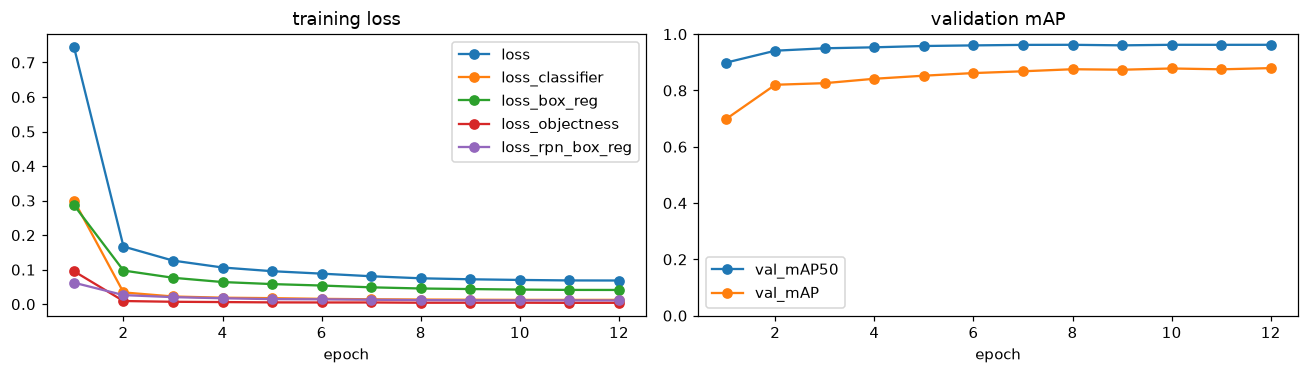

In [16]:
# curves from this session's training, or from the NRP run that produced CKPT
h = pd.DataFrame(history) if history else pd.read_csv(CKPT.parent / "history.csv")
if len(h):
    fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
    h.plot(x="epoch", y=["loss", "loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"], ax=a, marker="o")
    a.set_title("training loss")
    h.plot(x="epoch", y=["val_mAP50", "val_mAP"], ax=b, marker="o")
    b.set_title("validation mAP")
    b.set_ylim(0, 1)
    plt.tight_layout()

## 8. Evaluate: synthetic val vs. real OPEN100

- **val** is synthetic sheets similar to training. **test** is the 12 real OPEN100 drawings.
- The gap between the two is the synthetic-to-real gap.
- AP for `pump` and `tank` on test comes from very few boxes (16 and 35), so treat it as noisy.

In [17]:
import json

EVAL_LOCALLY = False  # True = recompute here (about 2-3 min on the Mac); False = use the NRP run's metrics.json
if EVAL_LOCALLY or not (CKPT.parent / "metrics.json").exists():
    results = {split: evaluate(model, split) for split in ["val", "test"]}
else:
    m = json.loads((CKPT.parent / "metrics.json").read_text())
    results = {"val": m["val"], "test": m["test_open100_real"]}
pd.DataFrame(
    {split: {"mAP@[.5:.95]": r["mAP"], "mAP@.5": r["mAP50"], **{f"AP {c}": v for c, v in r["per_class_AP"].items()}}
     for split, r in results.items()}
).round(3)

,val,test
mAP@[.5:.95],0.878,0.277
mAP@.5,0.962,0.390
AP general,0.791,0.039
AP instrument,0.894,0.802
AP pump,0.941,0.016
AP tank,0.974,0.123
AP valve,0.792,0.406


### Baseline results (NRP, RTX 4090, 2026-09-30)

Trained for 12 epochs at batch 2 with mixed precision, 1.05 min per epoch. Best checkpoint: epoch 10.

| | synthetic val | **real OPEN100** |
|---|---|---|
| mAP@.5 | 0.96 | **0.39** |
| instrument | 0.89 | **0.80** |
| valve | 0.79 | 0.41 |
| tank | 0.97 | **0.12** |
| pump | 0.94 | **0.02** |
| general | 0.79 | 0.04 |

**The synthetic-to-real gap is the main finding.**
- Instrument bubbles look the same everywhere, so they transfer well.
- Tanks and pumps come from a single synthetic symbol set. The model learned *that* drawing style, not "tank" in general, so on real sheets it misses almost all large equipment.

**On `pid_big.png`** (a real chemical-plant P&ID, a 1232×720 screenshot): 142 detections (66 valves, 46 instruments, 30 general).
- Instruments and valves are mostly right.
- The condenser and immersion vessel are found as `general`.
- The column/reactor (13K01/13R01) and the reflux pumps (13P01A/B) are **not** found.
- False positives: the off-page connector arrows (our dropped `inlet/outlet` class) and one box in the data tables.

**Most promising next steps**
1. Hand-label 20–50 real sheets (your own drawings, or public ones), fine-tune on them, and keep some for testing. Even a few real examples of columns and pumps should help most.
2. Augmentation that makes synthetic sheets look real: line-weight changes, blur, JPEG/scan noise, text clutter, random tables.
3. Bring back `inlet/outlet` as a class so the connector arrows get a proper label instead of `general`.
4. Use higher-resolution source images. Your sheet is a small screenshot, so small symbols are blurry.

## 9. Predict on any image

`predict(path)` accepts any PNG or JPG. It resizes the image the same way as in training, runs the model, maps the boxes back to the original image's pixels, draws them, and saves the picture to `out/`. It returns a table of detections.

`score_threshold` is the minimum confidence for a box to be kept. Lower it to see more (and less certain) detections.

In [18]:
OUT = ROOT / "out"


@torch.no_grad()
def predict(path, score_threshold: float = 0.5, show: bool = True, save: bool = True) -> pd.DataFrame:
    path = Path(path)
    img, scale = load_resized(path)
    model.eval()
    o = model([to_tensor(img).to(DEVICE)])[0]
    keep = o["scores"] >= score_threshold
    det = pd.DataFrame(o["boxes"][keep].cpu().numpy() / scale, columns=["xmin", "ymin", "xmax", "ymax"])
    det.insert(0, "cls", [ID_TO_CLASS[int(l)] for l in o["labels"][keep].cpu()])
    det.insert(1, "score", o["scores"][keep].cpu().numpy())

    if show or save:
        fig, ax = plt.subplots(figsize=(16, 16 * img.height / img.width))
        ax.imshow(img)
        draw_boxes(ax, (det[["xmin", "ymin", "xmax", "ymax"]].to_numpy() * scale).tolist(),
                   [CLASS_TO_ID[c] for c in det.cls], det.score.tolist())
        counts = ", ".join(f"{n} {c}" for c, n in det.cls.value_counts().items())
        ax.set_title(f"{path.name}: {len(det)} components ({counts})", fontsize=10)
        ax.axis("off")
        plt.tight_layout()
        if save:
            OUT.mkdir(exist_ok=True)
            fig.savefig(OUT / f"{path.stem}_pred.png", dpi=150, bbox_inches="tight")
        if not show:
            plt.close(fig)
    return det.sort_values("score", ascending=False, ignore_index=True)

,cls,score,xmin,ymin,xmax,ymax
0,general,0.999671,785.812561,463.813965,829.363220,500.437744
1,instrument,0.999539,1238.005493,415.839264,1279.519409,457.728180
2,instrument,0.999506,1665.826904,868.413757,1706.609985,909.540039
3,general,0.999451,590.896179,966.388245,673.822388,993.989502
4,valve,0.999430,1245.959473,653.373413,1267.532349,668.105652
5,instrument,0.999425,1684.513916,422.826752,1725.151733,463.379608
6,valve,0.999387,1555.037842,444.310486,1568.773926,465.875580
7,instrument,0.999267,1342.406860,387.863586,1383.039795,429.661682
8,instrument,0.999219,1763.685303,422.795410,1805.350952,463.593353
9,instrument,0.999218,933.981201,388.302795,974.803528,429.760040


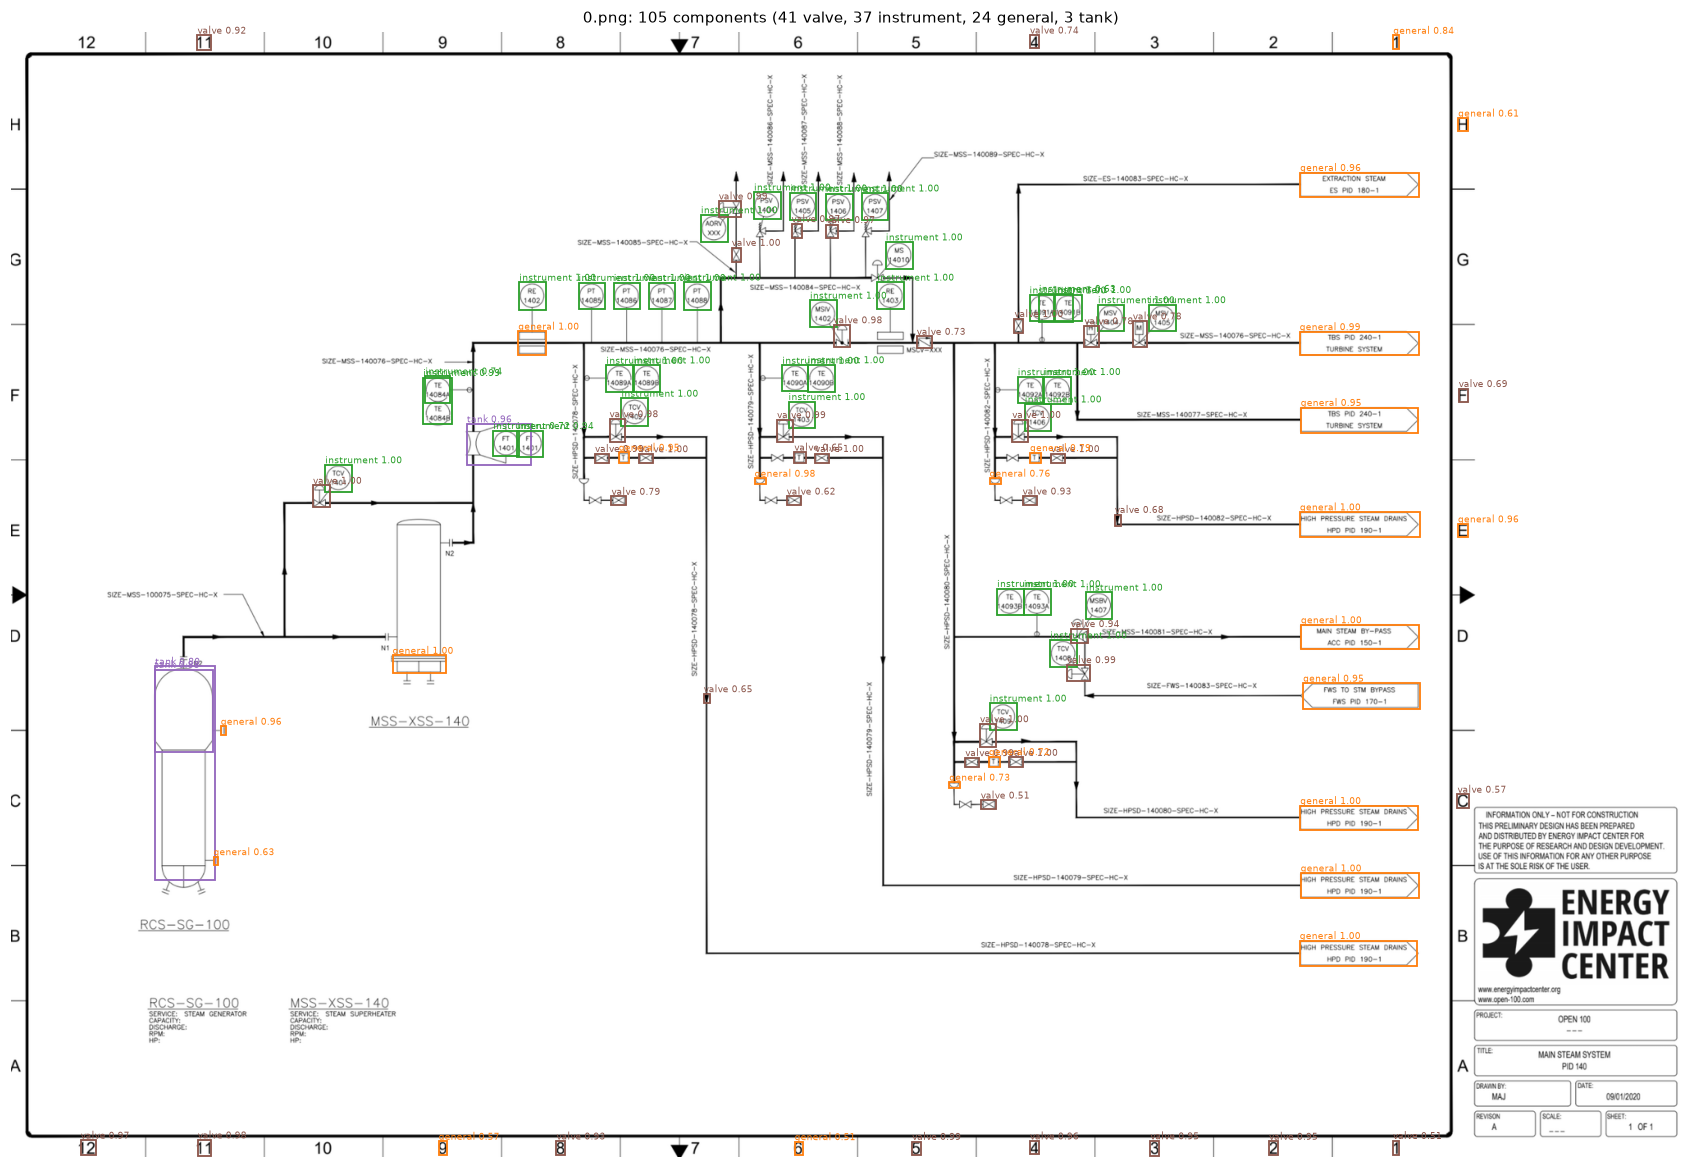

In [19]:
# a real sheet the model never trained on (predictions run locally with the NRP-trained weights)
det = predict(sheets.set_index("sheet").loc["PID2Graph OPEN100/0", "image"])
det.head(10)

cls
valve         66
instrument    46
general       30
Name: count, dtype: int64

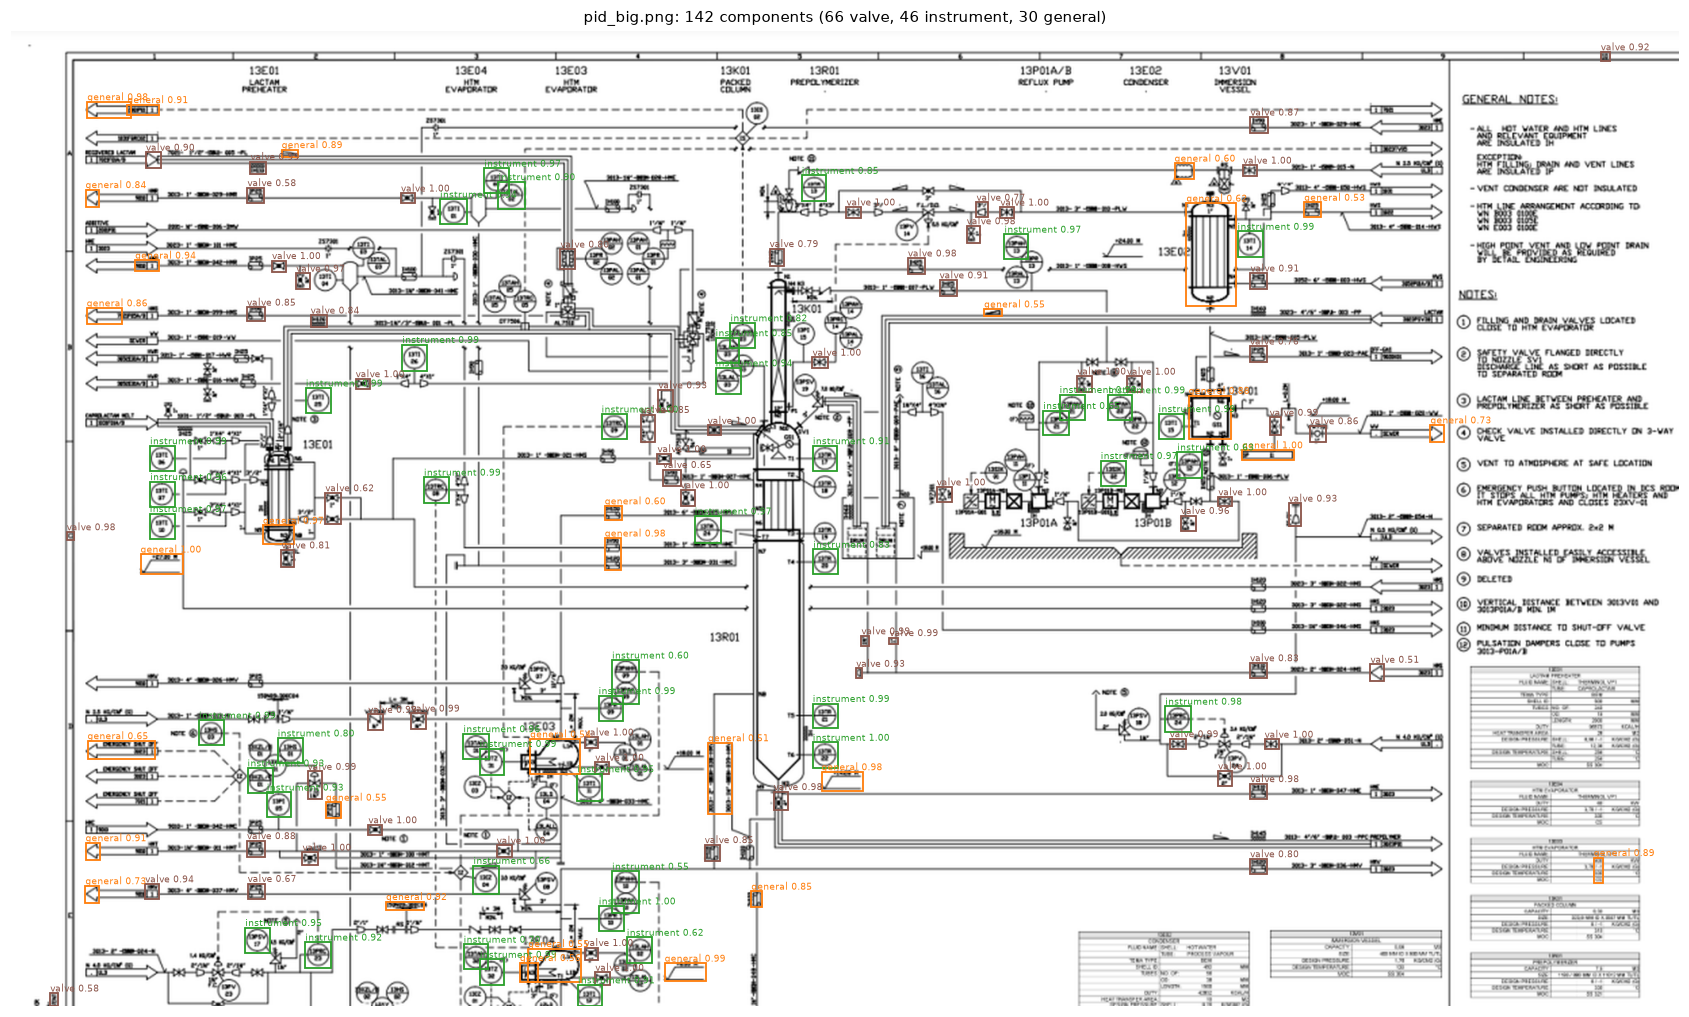

In [20]:
# your own images: put them in images/ (pid_big.png is already there)
det = predict(ROOT / "images" / "pid_big.png", score_threshold=0.5)
det.cls.value_counts()

## Next

- Look at the errors on the OPEN100 sheets: which classes are missed, and which are confused with each other?
- Retrain once Dataset PID has finished downloading. It adds many more `instrument` and `valve` examples.
- If real-sheet results lag far behind val, try augmentation that makes synthetic sheets look more like real ones (blur, line thickness, noise), or fine-tune on a few hand-labelled real sheets.